In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# СЧИТЫВАЕМ данные

In [2]:
# orders_xlsx = pd.read_excel('/Users/vladislavlipkin/Documents/PycharmProjects/Simulate/final_python_samokat/data/orders.xlsx') # MACOS
orders_xlsx = pd.read_excel(r'C:\Users\Incognitus\Documents\git_hub\Simulate\final_python_samokat\data\orders.xlsx') # WIN

In [3]:
# products_xlsx = pd.read_excel('/Users/vladislavlipkin/Documents/PycharmProjects/Simulate/final_python_samokat/data/products.xlsx') # MACOS
products_xlsx = pd.read_excel(r'C:\Users\Incognitus\Documents\git_hub\Simulate\final_python_samokat\data\products.xlsx') # WIN

# и что же там ?

In [4]:
orders_xlsx.head(5)

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74
1,1517430051,2022-01-13 16:46:53,17122,1,169,169,74
2,1517578174,2022-01-13 18:12:30,17122,1,169,169,74
3,1517466327,2022-01-13 15:11:12,22199,1,219,219,130
4,1517429157,2022-01-13 19:15:59,22199,1,219,219,130


In [5]:
products_xlsx.head(5)

,product_id,level1,level2,name
0,1,Гигиена,Бритье,Кассеты для бритья Gillette Fusion ProGlide Po...
1,2,Мучные кондитерские изделия,Мучные кондитерские изделия,Печенье Бодрость
2,3,Мясная гастрономия,"Сосиски, сардельки",Сосиски Стародворье
3,4,Чай,Черный чай,Чай Азерчай
4,5,Безалкогольные напитки,Соковая продукция,Морс Valio


# Описание таблиц

## Таблица products

| Колонка       | Описание                    |
|---------------|-----------------------------|
| product_id    | id товара                   |
| level1        | категория                   |
| level2        | подкатегория                |
| name          | наименование товара         |

## Таблица orders

| Колонка        | Описание                         |
|----------------|----------------------------------|
| order_id       | номер чека                       |
| accepted_at    | дата и время чека                |
| product_id     | id товара                        |
| quantity       | кол-во товара в чеке             |
| regular_price  | регулярная цена                  |
| price          | текущая цена                     |
| cost_price     | закупочная цена                  |

# TASKS

# 1. Самая ходовая товарная группа

## Задание
По какой категории товаров продано больше всего позиций?

## Требования
1. Подкрепите ответ таблицей, в которой рассчитано количество проданных штук товара в каждой товарной категории.
2. Дополнительно постройте на основании этой таблицы barchart.
3. Проверьте, чтобы все подписи на графике выглядели читаемо и понятно.
4. График должен быть сходу понятен стороннему наблюдателю.

In [6]:
merge_table = pd.merge(
    orders_xlsx
    , products_xlsx
    , on='product_id'
    , how='left'
)

In [7]:
merge_table.head(3)

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price,level1,level2,name
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан
1,1517430051,2022-01-13 16:46:53,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан
2,1517578174,2022-01-13 18:12:30,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан


In [14]:
agg_count_category = merge_table.groupby('level1').agg(
    quantity_of_products = ('quantity', 'sum')
).reset_index()

result_quantity_of_products = agg_count_category.sort_values('quantity_of_products', ascending=False).reset_index().head(5)
result_quantity_of_products

,index,level1,quantity_of_products
0,1,Безалкогольные напитки,534
1,11,Молочная продукция,483
2,19,Свежие овощи,262
3,10,Кулинария,250
4,0,Бакалея,239


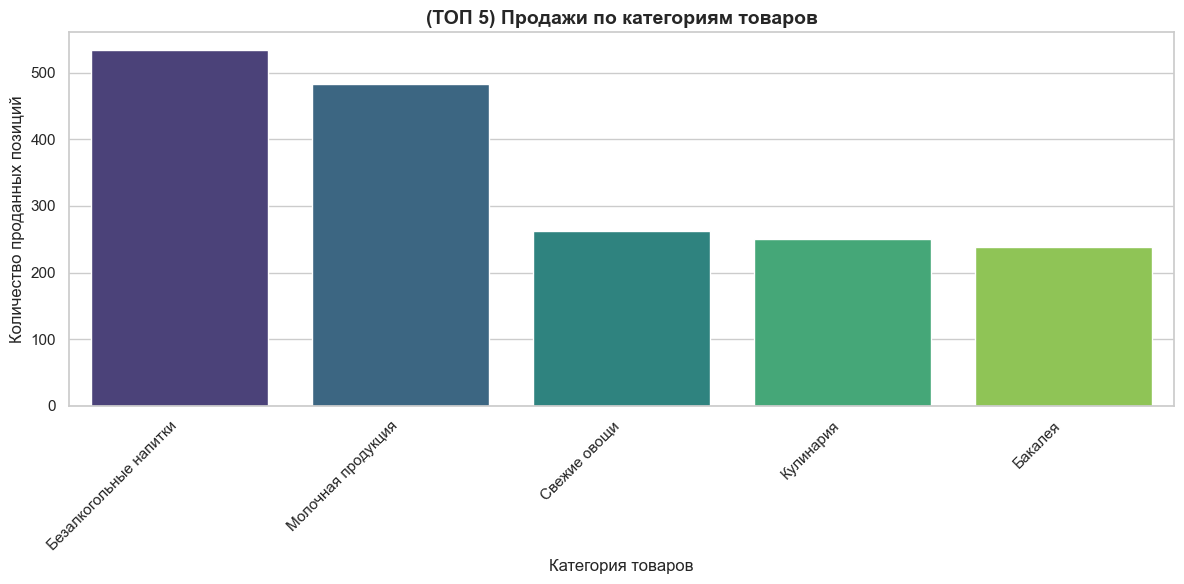

In [9]:
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.barplot(x='level1', y='quantity_of_products', data=result_quantity_of_products, palette='viridis')
plt.xlabel('Категория товаров', fontsize=12)
plt.ylabel('Количество проданных позиций', fontsize=12)
plt.title('(ТОП 5) Продажи по категориям товаров', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. Распределение продаж по подкатегориям

## Задание
Оцените распределение количества проданных позиций в каждой товарной категории (level1) по подкатегориям (level2). Проиллюстрируйте свой результат расчетной таблицей.

In [11]:
merge_table.head(1)

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price,level1,level2,name
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан


In [30]:
agg_count_subcategory = merge_table.groupby(['level1', 'level2']).agg(
    quantity_of_subcategory = ('quantity', 'sum')
).reset_index()

result_quantity_of_subcategory = agg_count_subcategory.sort_values(
    ['quantity_of_subcategory'], 
    ascending=[False]
).reset_index(drop=True)

result_quantity_of_subcategory.head(10)

,level1,level2,quantity_of_subcategory
0,Безалкогольные напитки,Напитки,252
1,Кулинария,Готовые блюда,248
2,Хлеб и хлебобулочные изделия,Хлеб и хлебобулочные изделия,218
3,Снэки,Снэки соленые,180
4,Безалкогольные напитки,Воды питьевые,162
5,Свежие овощи,"Корнеплоды, зелень и прочие овощи",157
6,Молочная продукция,Молоко и сливки,147
7,Молочная продукция,Молочно-десертные продукты,116
8,Свежие фрукты,"Цитрусовые, семечковые и прочие плоды",108
9,Молочная продукция,Кисломолочные традиционные продукты,106


# Найти средний чек в заданную дату

## Задание
Какой средний чек был 13.01.2022?

In [52]:
# создадим столбец с датой , и приведем в строку
merge_table['date'] = merge_table['accepted_at'].dt.date.astype(str)
# сделаем общую сумму по чеку с учетом количества
merge_table['total_price'] = merge_table['price'] * merge_table['quantity']
merge_table.head(3)

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price,level1,level2,name,date,total_price
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан,2022-01-13,169
1,1517430051,2022-01-13 16:46:53,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан,2022-01-13,169
2,1517578174,2022-01-13 18:12:30,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан,2022-01-13,169


In [47]:
filter_time = '2022-01-13'
jan13_avg_check = merge_table.query('date == @filter_time')

In [57]:
print(f'средний чек по заданой дате {filter_time}: -- {round(jan13_avg_check['total_price'].mean(), 2)} --')

средний чек по заданой дате 2022-01-13: -- 149.9 --


# Доля промо в заданной категории

## Описание задачи
Когда товар продается по промо-акции, его базовая цена не совпадает с фактической ценой.

## Задание
1. Посчитать, какую долю от общих продаж категории **Сыры** занимают промо (в штуках)
2. Построить пайчарт, который это проиллюстрирует
3. На графике должны быть видны группы, соответствующие доли и понятные подписи к ним